# Module 12: Molecular Visualization

The previous modules have focused on numerical and statistical data: spectra, distributions, surfaces, and time series. This module shifts to a different kind of scientific visualization: the 2D and 3D structure of molecules. For chemists and chemical engineers, being able to draw and inspect molecular structures programmatically is as fundamental as plotting a curve, and the same Python session that processes your data can generate publication-quality structure diagrams and interactive 3D viewers.

## Installation

This module uses two libraries not available by default in Colab. **RDKit** is the standard cheminformatics toolkit for Python: it handles SMILES parsing, 2D structure generation, substructure matching, and much more. **py3Dmol** is a lightweight wrapper around the 3Dmol.js JavaScript library that renders interactive 3D molecular structures directly in the notebook.

In [1]:
#!pip install rdkit --quiet

In [2]:
#!pip install py3Dmol --quiet

## Imports and Setup

In [3]:
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, Image, SVG
import py3Dmol

## 1. From SMILES to a 2D structure

A SMILES string (Simplified Molecular Input Line Entry System) encodes a molecular graph as a compact text string. RDKit parses it with `Chem.MolFromSmiles()`, which returns a molecule object. From there, `Draw.MolToImage()` computes a 2D layout and renders it as a PIL image. The 2D coordinates are generated automatically from the graph topology: you do not need to supply them.

In [4]:
# Define the four example molecules as SMILES strings
smiles_dict = {
    'Ethylene':  'C=C',
    'Styrene':   'C=Cc1ccccc1',
    'BHT':       'CC(C)(C)c1cc(C(C)(C)C)c(O)c(C(C)(C)C)c1',
    'Ibuprofen': 'CC(C)Cc1ccc(C(C)C(=O)O)cc1',
}

# Parse each SMILES into a molecule object
mols = {name: Chem.MolFromSmiles(smi) for name, smi in smiles_dict.items()}

# Confirm all parsed successfully (returns None on invalid SMILES)
for name, mol in mols.items():
    status = 'OK' if mol is not None else 'FAILED'
    print(f'{name:12s}  {smiles_dict[name]:45s}  {status}')

Ethylene      C=C                                            OK
Styrene       C=Cc1ccccc1                                    OK
BHT           CC(C)(C)c1cc(C(C)(C)C)c(O)c(C(C)(C)C)c1        OK
Ibuprofen     CC(C)Cc1ccc(C(C)C(=O)O)cc1                     OK


Ethylene


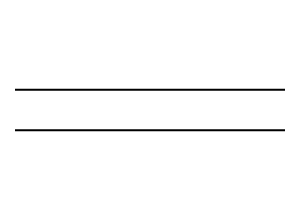

Styrene


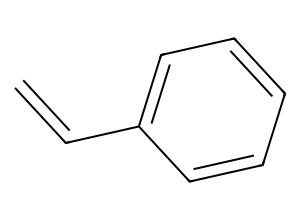

BHT


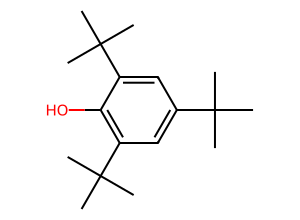

Ibuprofen


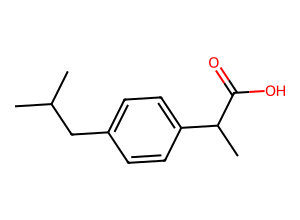

In [5]:
# Draw each molecule individually to inspect them before the grid
for name, mol in mols.items():
    img = Draw.MolToImage(mol, size=(300, 220))
    print(name)
    display(img)

`Draw.MolToImage()` returns a PIL `Image` object. The `size` argument sets the pixel dimensions of the output. The 2D layout algorithm places atoms to minimize bond crossings; for larger molecules like BHT the ring system is drawn first and the substituents radiate outward.

## 2. Drawing a grid of molecules

`Draw.MolsToGridImage()` arranges multiple molecules in a single image with consistent scaling and optional labels. This is the standard way to display a compound library, a monomer set, or a series of structures for comparison in one figure.

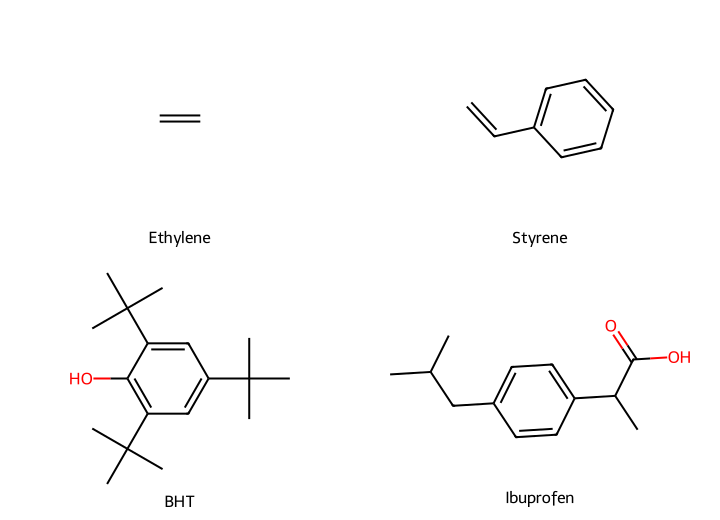

In [6]:
mol_list   = list(mols.values())
label_list = list(mols.keys())

grid_img = Draw.MolsToGridImage(
    mol_list,
    molsPerRow=2,
    subImgSize=(360, 260),
    legends=label_list
)

display(grid_img)

The `legends` argument places a text label below each structure. `molsPerRow` controls the grid layout: two columns here keeps each structure large enough to read clearly. For a set of ten or twenty structures you would increase `molsPerRow` and reduce `subImgSize` to fit them on one page.

## 3. Highlighting a substructure

Substructure highlighting marks specific atoms and bonds in a 2D drawing, typically to draw attention to a reactive site, a pharmacophore, or a functional group that drives a property of interest. The workflow is: define the substructure as a SMARTS pattern, use `mol.GetSubstructMatch()` to find the matching atom indices in the target molecule, and pass those indices to the drawing function.

BHT (butylated hydroxytoluene) is a hindered phenol antioxidant widely used in polyolefins: the hydroxyl group is the active site that donates a hydrogen to quench peroxy radicals. Highlighting the OH makes the reactive centre immediately visible.

Matching atom indices for phenolic OH: (11, 12)


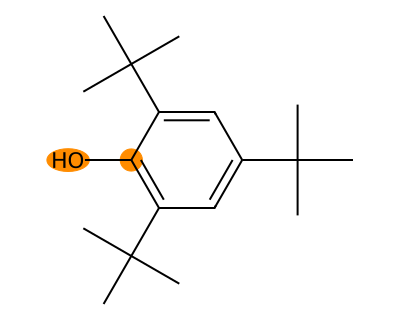

In [7]:
mol_bht = mols['BHT']

# SMARTS pattern for a phenolic OH: aromatic carbon bonded to an oxygen bearing one hydrogen
oh_smarts = Chem.MolFromSmarts('[c][OH]')

# GetSubstructMatch returns a tuple of atom indices for the first match
match_indices = mol_bht.GetSubstructMatch(oh_smarts)
print(f'Matching atom indices for phenolic OH: {match_indices}')

# Draw with those atoms highlighted in a warm color
highlight_colors = {idx: (1.0, 0.55, 0.0) for idx in match_indices}   # orange

drawer = rdMolDraw2D.MolDraw2DSVG(400, 320)
drawer.drawOptions().addAtomIndices = False
rdMolDraw2D.PrepareAndDrawMolecule(
    drawer,
    mol_bht,
    highlightAtoms=list(match_indices),
    highlightAtomColors=highlight_colors
)
drawer.FinishDrawing()
svg_bht = drawer.GetDrawingText()

display(SVG(svg_bht))

The orange highlight marks the aromatic carbon and the oxygen of the phenolic OH group. `rdMolDraw2D` gives finer control over the drawing than `Draw.MolToImage`: it returns SVG text, which is vector-format and scales without pixelation. The `highlightAtomColors` dictionary maps each atom index to an RGB tuple, so different functional groups in the same molecule can be highlighted in different colors.

## 4. Draw your own molecule

Replace the SMILES string in `USER_SMILES` below with any molecule you want to visualize. Valid SMILES strings can be found on PubChem, ChemDraw, or any cheminformatics database. The same variable is reused later for 3D visualization, so changing it once affects both outputs.

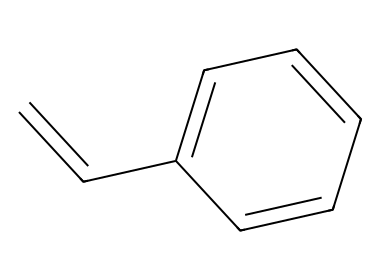

Atoms: 8  |  Bonds: 8


In [8]:
# Replace this SMILES with any molecule you want to visualize
USER_SMILES = 'C=Cc1ccccc1'   # styrene (default)

mol_user = Chem.MolFromSmiles(USER_SMILES)

if mol_user is None:
    print('Invalid SMILES. Check the string and try again.')
else:
    img_user = Draw.MolToImage(mol_user, size=(380, 280))
    display(img_user)
    print(f'Atoms: {mol_user.GetNumAtoms()}  |  Bonds: {mol_user.GetNumBonds()}')

The atom and bond count confirms that RDKit parsed the structure correctly. If you enter a SMILES that RDKit cannot parse, `MolFromSmiles()` returns `None` and the cell prints a clear error message rather than crashing.

## 5. 3D visualization with py3Dmol

A 2D structure drawing is a graph: it shows connectivity but not the three-dimensional arrangement of atoms. For understanding steric effects, molecular packing, and conformation, a 3D view is necessary. The workflow is: add explicit hydrogens to the molecule, embed it in 3D space with a distance-geometry algorithm, optimize the geometry with a force field, export to Molfile format, and pass the text to py3Dmol for rendering.

`AllChem.EmbedMolecule()` generates an initial 3D conformer from the molecular graph. `AllChem.MMFFOptimizeMolecule()` refines it with the MMFF94 force field, which gives a geometry close to the true minimum-energy conformation for drug-like molecules and common organic structures.

In [9]:
# Add explicit hydrogens before 3D embedding: required for a correct geometry
mol_bht_3d = Chem.AddHs(mols['BHT'])

# Embed: place atoms in 3D space using distance geometry
# randomSeed ensures the same conformer is generated each run
embed_result = AllChem.EmbedMolecule(mol_bht_3d, randomSeed=42)

if embed_result == -1:
    print('Embedding failed. Try a different random seed or check the SMILES.')
else:
    # Optimize geometry with MMFF94 force field
    ff_result = AllChem.MMFFOptimizeMolecule(mol_bht_3d)
    status_map = {0: 'converged', 1: 'not converged', -1: 'FF setup failed'}
    print(f'MMFF optimization: {status_map.get(ff_result, "unknown")}')

    # Export to Molfile (V2000 format) as a string
    molblock_bht = Chem.MolToMolBlock(mol_bht_3d)
    print(f'Molfile generated: {len(molblock_bht.splitlines())} lines')

MMFF optimization: converged
Molfile generated: 103 lines


In [10]:
# Create a py3Dmol viewer and load the Molfile
view_bht = py3Dmol.view(width=500, height=380)
view_bht.addModel(molblock_bht, 'mol')

# Default style: stick representation
view_bht.setStyle({'stick': {}})

# Center the molecule and zoom to fit the viewer window
view_bht.zoomTo()
view_bht.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

The 3D viewer is interactive: click and drag to rotate, scroll to zoom, and right-click to translate. The three tert-butyl groups on the ring are clearly visible as tetrahedral carbon centres, and the ring is planar as expected for an aromatic system. The force-field optimization has placed all groups in reasonable low-energy positions.

## 6. Display styles in py3Dmol

py3Dmol supports several rendering styles. The three most common are: **stick**, which draws bonds as cylinders and atoms as small spheres at bond junctions; **sphere**, which draws each atom as a van der Waals sphere with no explicit bonds, giving a space-filling view; and **line**, which draws bonds as thin lines, useful when you want a lightweight rendering for a large molecule. You can mix styles by calling `setStyle` with element- or residue-based selectors.

In [11]:
style_configs = [
    ('Stick',   {'stick': {}}),
    ('Sphere',  {'sphere': {'scale': 0.4}}),   # scale < 1 keeps spheres readable
    ('Line',    {'line': {}}),
]

for style_name, style_dict in style_configs:
    print(f'--- {style_name} ---')
    v = py3Dmol.view(width=480, height=350)
    v.addModel(molblock_bht, 'mol')
    v.setStyle(style_dict)
    v.setBackgroundColor('0xf8f8f8')   # light grey background for contrast
    v.zoomTo()
    v.show()

--- Stick ---


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

--- Sphere ---


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

--- Line ---


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

The stick representation is the most informative for a small organic molecule: bond order is implicit in the geometry and bond lengths are readable. Sphere (space-filling) is useful when you want to see how much volume a molecule occupies and which parts are sterically accessible. The BHT hydroxyl oxygen is clearly buried between two bulky tert-butyl groups in the sphere view, which is exactly the steric protection that makes BHT an effective antioxidant: the OH is accessible enough to donate a hydrogen to a radical, but shielded enough to resist further oxidation.

## 7. 3D visualization for your own molecule

The cell below uses the same `USER_SMILES` variable from section 4. If you have already changed it to a molecule of interest, run this cell directly. If not, go back to section 4, change `USER_SMILES`, and run both cells.

In [12]:
if mol_user is None:
    print('USER_SMILES was not parsed successfully. Go back to section 4 and fix it first.')
else:
    mol_user_3d = Chem.AddHs(mol_user)
    embed_user = AllChem.EmbedMolecule(mol_user_3d, randomSeed=42)

    if embed_user == -1:
        # Some very small or unusual molecules cannot be embedded; try UFF as fallback
        print('MMFF embedding failed, trying UFF force field...')
        AllChem.EmbedMolecule(mol_user_3d, AllChem.ETKDGv3())
        AllChem.UFFOptimizeMolecule(mol_user_3d)
    else:
        AllChem.MMFFOptimizeMolecule(mol_user_3d)

    molblock_user = Chem.MolToMolBlock(mol_user_3d)

    view_user = py3Dmol.view(width=500, height=380)
    view_user.addModel(molblock_user, 'mol')
    view_user.setStyle({'stick': {}})
    view_user.setBackgroundColor('0xf8f8f8')
    view_user.zoomTo()
    view_user.show()

    print(f'Molecule: {USER_SMILES}')
    print(f'Heavy atoms: {mol_user.GetNumAtoms()}  |  Atoms incl. H: {mol_user_3d.GetNumAtoms()}')

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Molecule: C=Cc1ccccc1
Heavy atoms: 8  |  Atoms incl. H: 16


The cell adds a UFF fallback for molecules that MMFF cannot handle (very small fragments, unusual elements). For typical organic monomers and additives the MMFF path will succeed. If you try a polymer repeat unit such as a vinyl monomer, the 3D viewer shows the local chain geometry around one monomer unit, which can be useful for visualizing tacticity or pendant group orientation.